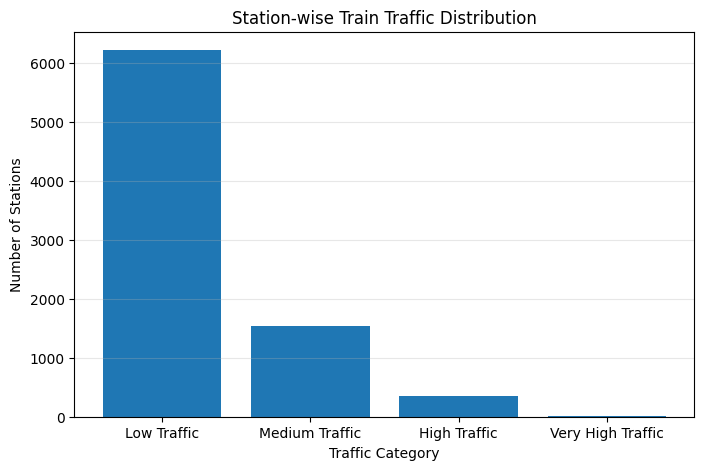

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Dataset1.csv")


# Count trains passing through each station

station_traffic = df.groupby("Station_Name")["Train_No"].nunique().reset_index()

station_traffic.columns = ["Station_Name", "Train_Count"]


# Create traffic categories

station_traffic["Traffic_Level"] = pd.cut(
    station_traffic["Train_Count"],
    bins=[0,20,100,500,2000],
    labels=[
        "Low Traffic",
        "Medium Traffic",
        "High Traffic",
        "Very High Traffic"
    ]
)


# Count stations in each category

traffic_summary = station_traffic["Traffic_Level"].value_counts().sort_index()


# Plot

plt.figure(figsize=(8,5))

plt.bar(
    traffic_summary.index,
    traffic_summary.values
)

plt.xlabel("Traffic Category")
plt.ylabel("Number of Stations")

plt.title("Station-wise Train Traffic Distribution")

plt.grid(axis="y", alpha=0.3)

plt.show()